In [67]:
from tqdm import tqdm
import polars as pl
import numpy as np
import catboost as cb
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge, LinearRegression

music = pl.read_csv('data/charts.csv')
data = pl.read_csv('data/prices.csv')
music = music.filter(pl.col('chart') == 'top200')
music = music.drop(['artist', 'chart', 'rank', 'url'])

regions = music['region'].unique()

music = music.with_columns(pl.col('streams').sum().over('region', 'date').alias('S'))
music = music.unique(['region', 'date']).sort('date')
print(music)

dates = data['Date']
Y = np.concat([np.diff(data['XLU_Close'].to_numpy()), [0]])
# Y = np.concat([np.diff(data['XLP_Close'].to_numpy()), [0]])
print(Y.shape, len(dates))

X = []

for d in tqdm(dates):
    s = []
    for r in regions:
        v = music.filter((pl.col('region') == r) & (pl.col('date') == d))['S'].to_list()
        if len(v) > 0:
            s.append(v[0])
        else:
            s.append(0)
    X.append(s)
X = np.array(X)
print(X.shape)
print(X, Y)

shape: (109_991, 6)
┌─────────────────────────┬────────────┬──────────────────────┬───────────────┬─────────┬──────────┐
│ title                   ┆ date       ┆ region               ┆ trend         ┆ streams ┆ S        │
│ ---                     ┆ ---        ┆ ---                  ┆ ---           ┆ ---     ┆ ---      │
│ str                     ┆ str        ┆ str                  ┆ str           ┆ i64     ┆ i64      │
╞═════════════════════════╪════════════╪══════════════════════╪═══════════════╪═════════╪══════════╡
│ Starboy                 ┆ 2017-01-01 ┆ Luxembourg           ┆ MOVE_UP       ┆ 1020    ┆ 1020     │
│ Chantaje (feat. Maluma) ┆ 2017-01-01 ┆ Mexico               ┆ SAME_POSITION ┆ 395069  ┆ 14430216 │
│ Starboy                 ┆ 2017-01-01 ┆ Greece               ┆ SAME_POSITION ┆ 4209    ┆ 59509    │
│ Alone                   ┆ 2017-01-01 ┆ Spain                ┆ MOVE_UP       ┆ 25347   ┆ 6020628  │
│ Alone                   ┆ 2017-01-01 ┆ Norway               ┆ SAME_PO

100%|██████████████████████████████████████████████████████████████████████████████████████| 1152/1152 [00:27<00:00, 42.62it/s]

(1152, 69)
[[ 1455848  5921907  1831544 ... 14125246   984789    66945]
 [ 1500300  6019573  1835317 ... 13723670   983604    63221]
 [ 1504362  6223646  1785771 ... 13585922   994569    54583]
 ...
 [ 2663890 14236092 13033888 ... 32270731  1873327   606791]
 [ 2585254 15181981 13005961 ... 32893698  1943888   613131]
 [ 2646800 16814964 13293458 ... 34507982  2196447   773691]] [ 0.06721115  0.01867294  0.05600929 ...  0.07792473 -0.24242401
  0.        ]


In [206]:
Y = np.concat([np.diff(data['XLU_Close'].to_numpy()), [0]])
Y = data['XLU_Close'].to_numpy()
XX = X / (X.sum(1, keepdims=True) + 1e-8)
print(XX)
X_train, X_val, Y_train, Y_val = train_test_split(XX, Y, shuffle=False, test_size=0.9)

model = cb.CatBoostRegressor(depth=3, verbose=0)
# model = Ridge(0.01)
model.fit(X_train, Y_train)
print(model.score(X_train, Y_train))
print(model.score(X_val, Y_val))

[[0.00387356 0.01575634 0.00487316 ... 0.03758285 0.00262022 0.00017812]
 [0.00391615 0.01571257 0.00479063 ... 0.03582216 0.00256745 0.00016502]
 [0.00389864 0.01612895 0.00462793 ... 0.03520873 0.00257749 0.00014146]
 ...
 [0.00367095 0.01961795 0.01796126 ... 0.04447045 0.00258153 0.00083618]
 [0.0035129  0.02062961 0.01767279 ... 0.04469669 0.0026414  0.00083314]
 [0.00324608 0.02062215 0.01630331 ... 0.04232115 0.00269376 0.00094887]]
0.9991410235137584
-2.207525529037468


In [193]:
X, Y

(array([[ 1455848,  5921907,  1831544, ..., 14125246,   984789,    66945],
        [ 1500300,  6019573,  1835317, ..., 13723670,   983604,    63221],
        [ 1504362,  6223646,  1785771, ..., 13585922,   994569,    54583],
        ...,
        [ 2663890, 14236092, 13033888, ..., 32270731,  1873327,   606791],
        [ 2585254, 15181981, 13005961, ..., 32893698,  1943888,   613131],
        [ 2646800, 16814964, 13293458, ..., 34507982,  2196447,   773691]],
       shape=(1152, 69)),
 array([40.50434875, 40.50434875, 40.63702011, ..., 62.68442917,
        62.99325943, 63.09913635], shape=(1152,)))

In [194]:
import matplotlib.pyplot as plt

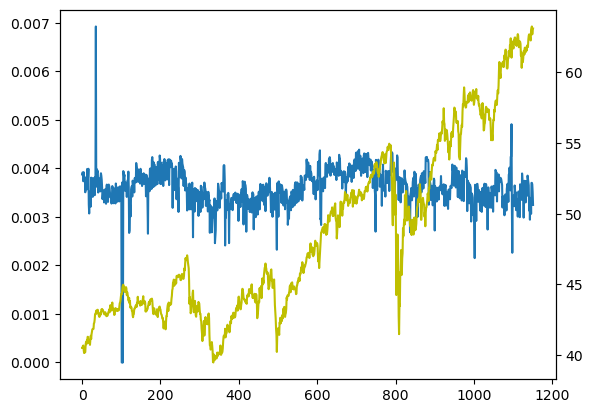

In [195]:
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(XX[:, 0])
ax2.plot(Y, c='y')